## Modelado del sistema con NARX (3 retardos)

En este notebook se aborda el modelado del sistema carrito-péndulo utilizando un enfoque NARX con 3 retardos. Para ello, se emplea un dataset combinado que integra diferentes tipos de excitación (chirp, random y control), con el objetivo de mejorar la capacidad de generalización del modelo.

Se entrenan dos tipos de modelos:
- Un modelo de regresión lineal como referencia (baseline)
- Un modelo no lineal basado en una red neuronal (MLP)

Ambos modelos se evalúan en predicción a un paso mediante el error cuadrático medio (MSE) y mediante la comparación visual entre valores reales y predichos. Esto permite analizar hasta qué punto la dinámica del sistema puede ser capturada mediante modelos lineales y no lineales.

Shape: (29994, 19)
MSE lineal: 0.010456299824304795
MSE MLP: 0.010107814819415981


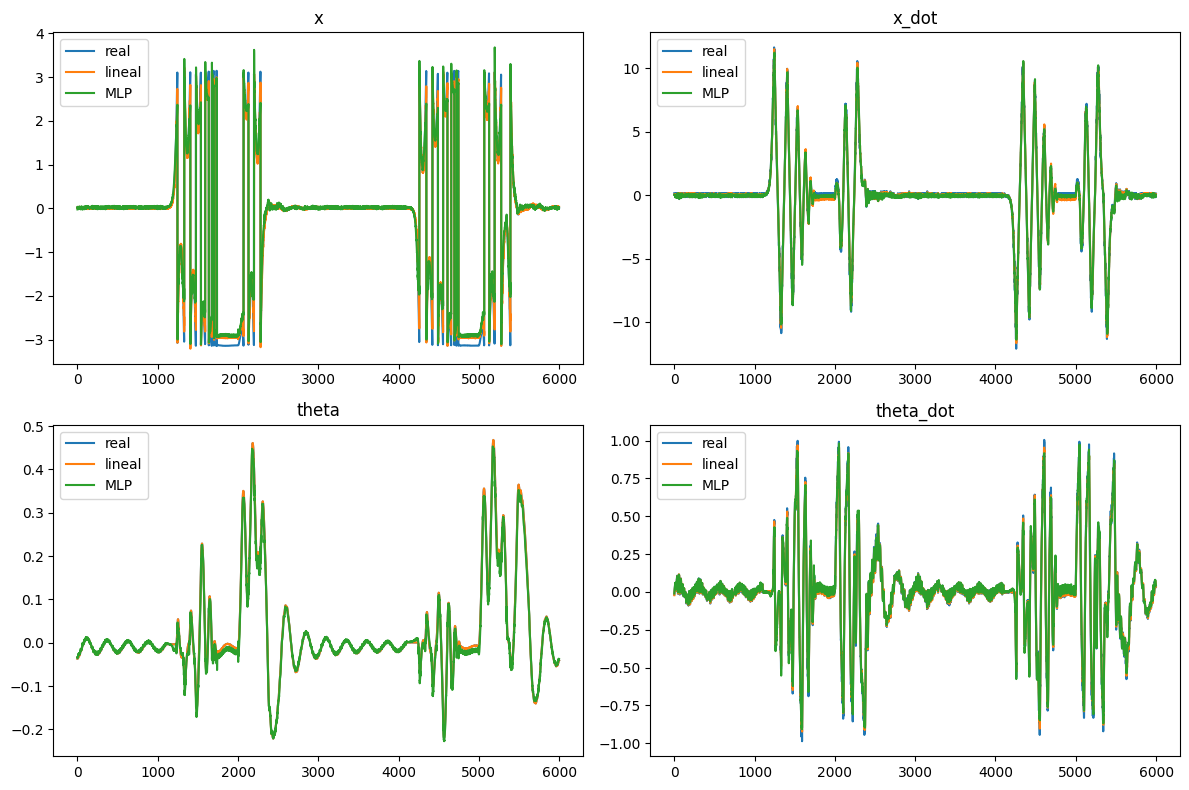

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

# =========================
# CARGA Y LIMPIEZA
# =========================
df = pd.read_csv(r"C:\Users\alber\OneDrive\Desktop\control automático\control-autom-tico\Data\real\dataset_3_total.csv")

# eliminar cabeceras duplicadas
df = df[df["x_k"] != "x_k"]

# convertir a numérico
df = df.apply(pd.to_numeric)

print("Shape:", df.shape)

# =========================
# SEPARAR X e Y
# =========================
Y = df[["x_k", "x_dot_k", "theta_k", "theta_dot_k"]].values
X = df.drop(columns=["x_k", "x_dot_k", "theta_k", "theta_dot_k"]).values

# =========================
# SPLIT TEMPORAL
# =========================
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
Y_train, Y_test = Y[:split], Y[split:]

# =========================
# NORMALIZACIÓN
# =========================
sx = StandardScaler()
sy = StandardScaler()

X_train = sx.fit_transform(X_train)
X_test = sx.transform(X_test)

Y_train = sy.fit_transform(Y_train)
Y_test = sy.transform(Y_test)

# =========================
# MODELO LINEAL
# =========================
lin = LinearRegression()
lin.fit(X_train, Y_train)

Y_pred_lin = lin.predict(X_test)
mse_lin = mean_squared_error(Y_test, Y_pred_lin)

print("MSE lineal:", mse_lin)

# =========================
# MODELO MLP
# =========================
mlp = MLPRegressor(hidden_layer_sizes=(32,32), max_iter=500, random_state=42)
mlp.fit(X_train, Y_train)

Y_pred_mlp = mlp.predict(X_test)
mse_mlp = mean_squared_error(Y_test, Y_pred_mlp)

print("MSE MLP:", mse_mlp)

# =========================
# DESNORMALIZAR
# =========================
Y_test_real = sy.inverse_transform(Y_test)
Y_lin_real = sy.inverse_transform(Y_pred_lin)
Y_mlp_real = sy.inverse_transform(Y_pred_mlp)

# =========================
# PLOT COMPARACIÓN
# =========================
labels = ["x", "x_dot", "theta", "theta_dot"]

plt.figure(figsize=(12,8))

for i in range(4):
    plt.subplot(2,2,i+1)
    plt.plot(Y_test_real[:,i], label="real")
    plt.plot(Y_lin_real[:,i], label="lineal")
    plt.plot(Y_mlp_real[:,i], label="MLP")
    plt.title(labels[i])
    plt.legend()

plt.tight_layout()
plt.show()

## Análisis de resultados: modelo lineal vs MLP

Se comparan los resultados obtenidos mediante un modelo de regresión lineal y un modelo no lineal basado en una red neuronal (MLP) para la predicción a un paso del sistema.

De forma general, ambos modelos son capaces de aproximar adecuadamente la dinámica del sistema, lo que indica que una parte significativa del comportamiento puede ser capturada mediante relaciones lineales. Sin embargo, se observan diferencias relevantes en determinadas regiones:

- En las variables relacionadas con la posición del carrito (`x`) y su velocidad (`x_dot`), el modelo MLP muestra una mejor capacidad para seguir transiciones bruscas y picos, reduciendo errores en zonas de mayor variabilidad.
- En las variables del péndulo (`theta` y `theta_dot`), ambos modelos presentan un comportamiento muy similar, aunque el MLP ofrece una ligera mejora en la captura de oscilaciones y amplitudes.

En conjunto, el modelo MLP presenta una mejora respecto al modelo lineal, especialmente en regiones donde la dinámica del sistema es más no lineal. No obstante, esta mejora no es drástica, lo que sugiere que el sistema puede ser parcialmente descrito mediante modelos lineales en el contexto de predicción a un paso.

Este análisis pone de manifiesto la necesidad de evaluar los modelos en condiciones más exigentes, como la simulación recursiva, donde las diferencias entre modelos suelen hacerse más evidentes.

## Modelo base (predicción del último estado)

Se define un modelo base en el que la predicción del estado actual es igual al estado anterior:

y(k) = y(k-1)

Este modelo sirve como referencia para evaluar si los modelos de machine learning realmente aportan mejora.

MSE baseline: 0.06514276710731567


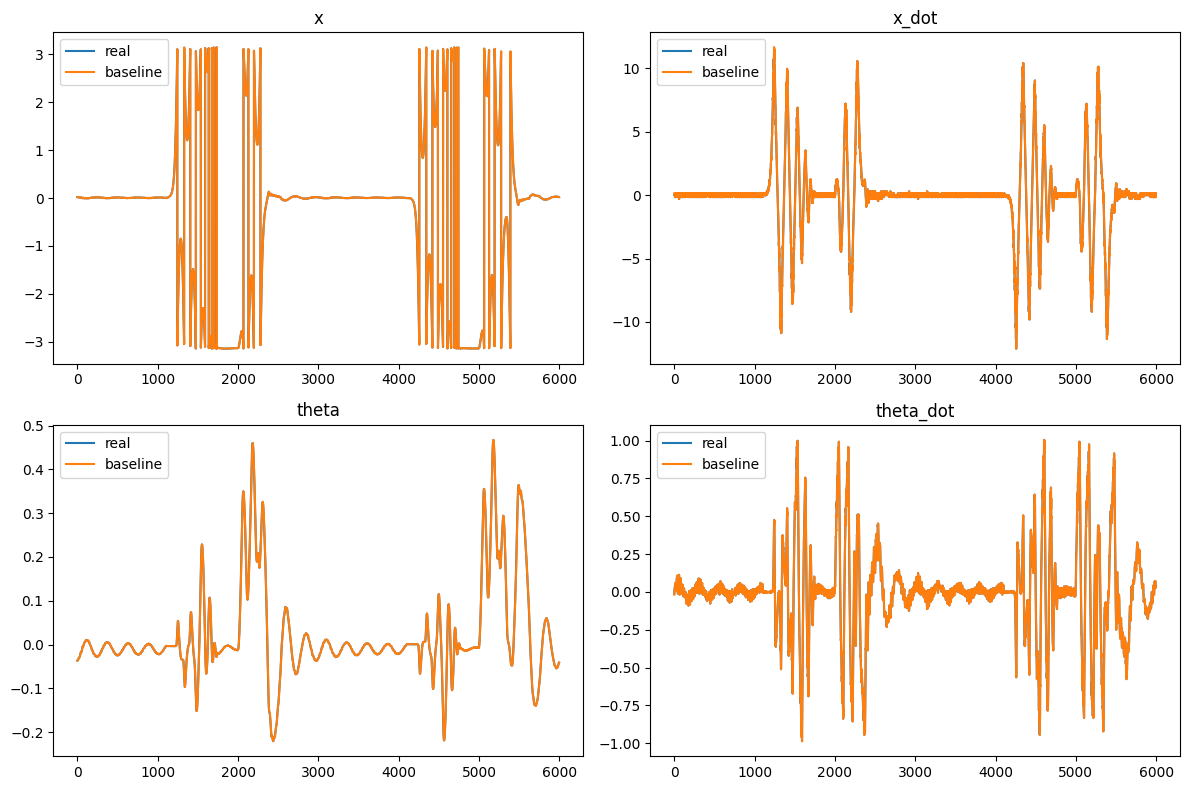

In [7]:
# =========================
# MODELO BASE
# =========================

# predicción: valor anterior
Y_pred_base = np.zeros_like(Y_test_real)

# desplazamiento temporal
Y_pred_base[1:] = Y_test_real[:-1]

# quitamos el primer punto (no válido)
Y_pred_base_valid = Y_pred_base[1:]
Y_test_base_valid = Y_test_real[1:]

# =========================
# MSE BASE
# =========================
mse_base = mean_squared_error(Y_test_base_valid, Y_pred_base_valid)

print("MSE baseline:", mse_base)

# =========================
# PLOT BASELINE
# =========================
labels = ["x", "x_dot", "theta", "theta_dot"]

plt.figure(figsize=(12,8))

for i in range(4):
    plt.subplot(2,2,i+1)
    plt.plot(Y_test_base_valid[:,i], label="real")
    plt.plot(Y_pred_base_valid[:,i], label="baseline")
    plt.title(labels[i])
    plt.legend()

plt.tight_layout()
plt.show()

Dataset cargado — shape: (29994, 19)

── Verificación de rangos (confirma el orden de columnas) ──
  col 0 (θ (rad)):  min=-3.1416  max=3.1401
  col 1 (θ_dot (rad/s)):  min=-12.1184  max=11.6583
  col 2 (x (m)):  min=-0.2209  max=0.4675
  col 3 (x_dot (m/s)):  min=-0.9874  max=1.0053

Variable             MSE Base    MSE Lin    MSE MLP    MAE Lin    MAE MLP
──────────────────────────────────────────────────────────────────────
θ (rad)              0.194344   0.189095   0.084673   0.095024   0.064595
θ_dot (rad/s)        0.065434   0.048689   0.029859   0.151926   0.112788
x (m)                0.000008   0.000000   0.000014   0.000144   0.002522
x_dot (m/s)          0.000785   0.000478   0.000310   0.014436   0.011338


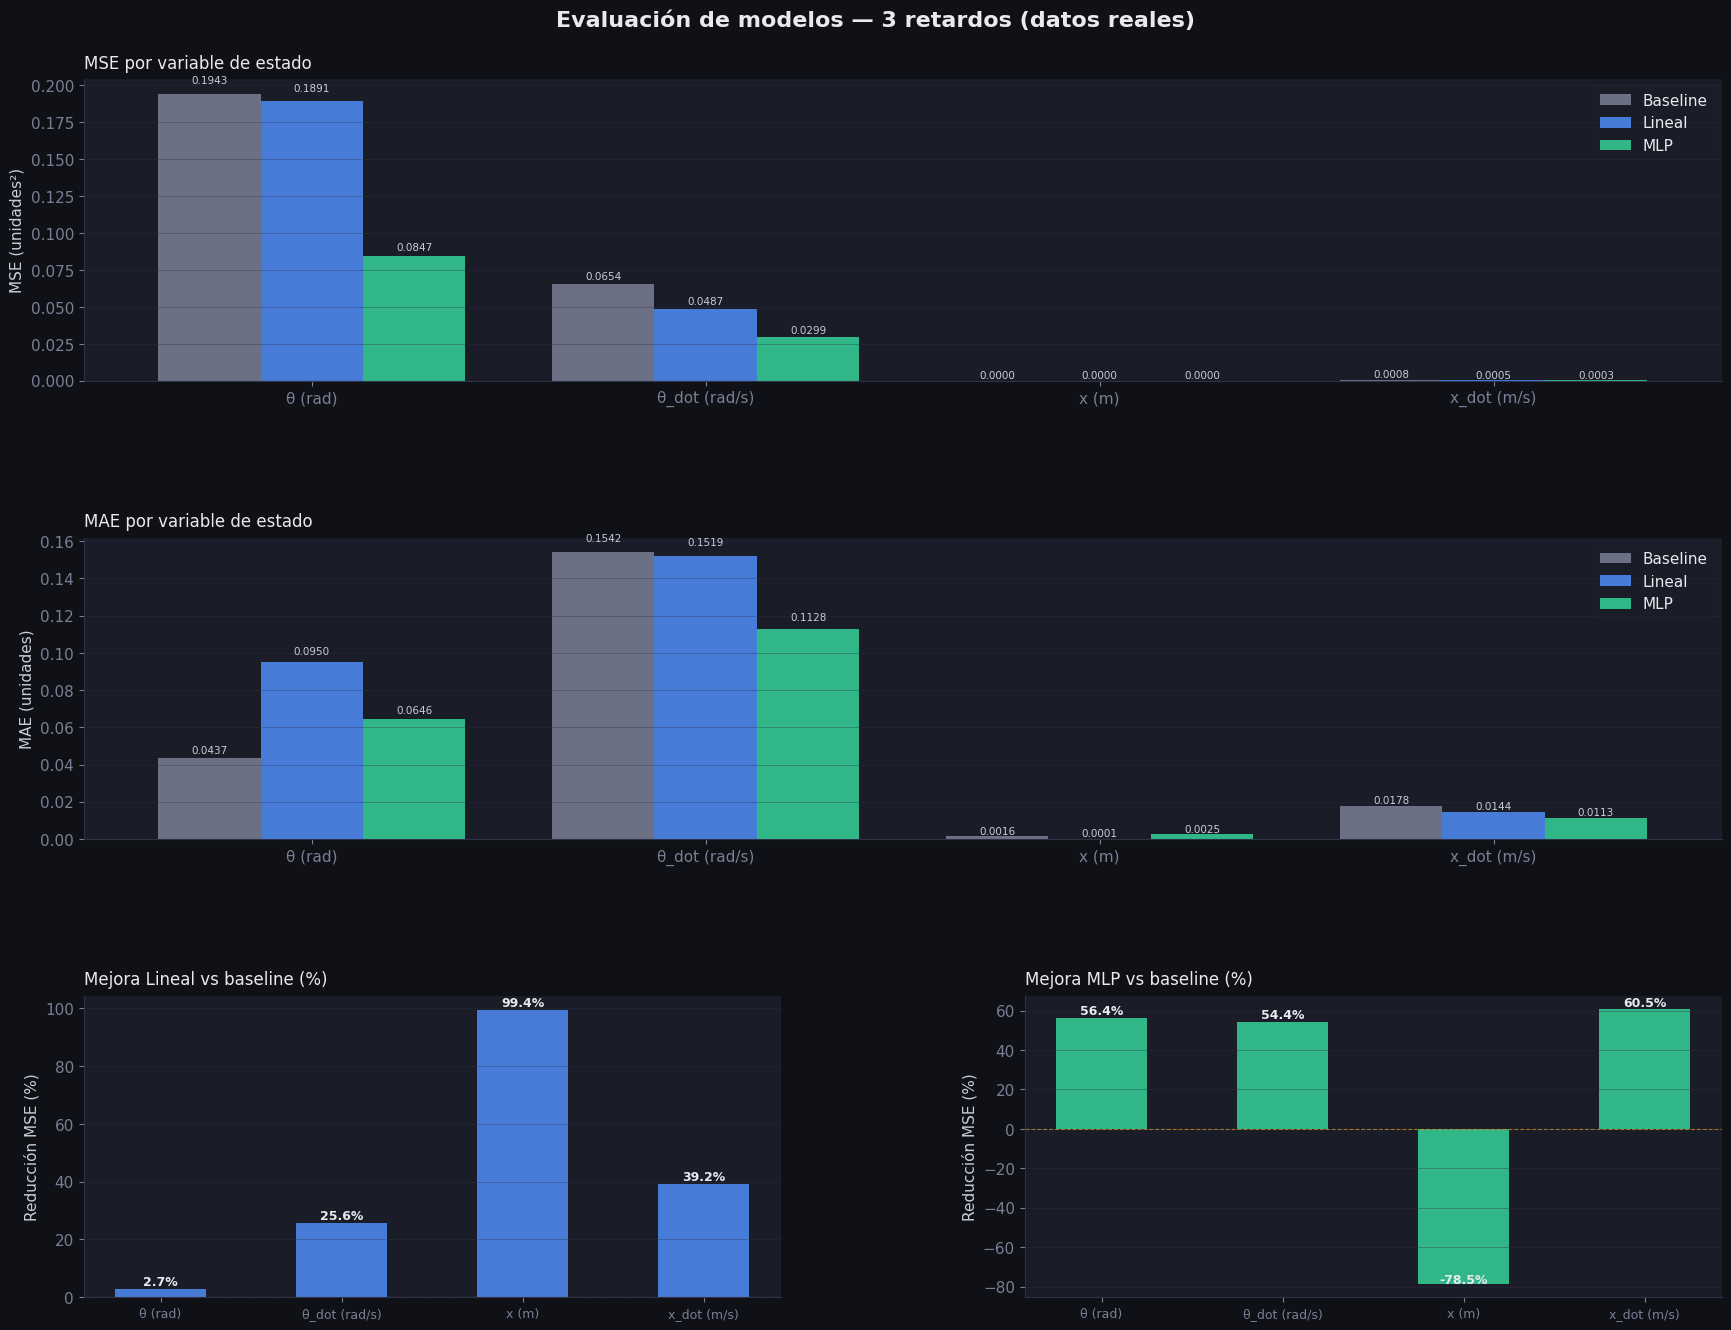

✓ Figura guardada como metricas_3retardos_corregido.png


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# ── Estilo global ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#2e3148',
    'axes.labelcolor':  '#c9cdd8',
    'xtick.color':      '#7a7f96',
    'ytick.color':      '#7a7f96',
    'text.color':       '#e8eaf0',
    'grid.color':       '#2e3148',
    'grid.linewidth':   0.6,
    'font.family':      'DejaVu Sans',
    'font.size':        11,
})

COLORS = {
    'baseline': '#7a7f96',
    'lineal':   '#4e8ef7',
    'mlp':      '#36d399',
    'accent':   '#f6a623',
    'bg_card':  '#1e2130',
    'border':   '#2e3148',
}

# ⚠️ ORDEN CORRECTO según rangos reales del dataset
# col 0 → theta, col 1 → theta_dot, col 2 → x, col 3 → x_dot
LABELS = ["θ (rad)", "θ_dot (rad/s)", "x (m)", "x_dot (m/s)"]
UNITS  = ["rad",     "rad/s",         "m",     "m/s"]

# ══════════════════════════════════════════════════════════════════════════════
# 1 · CARGA Y LIMPIEZA
# ══════════════════════════════════════════════════════════════════════════════
df = pd.read_csv(r"C:\Users\alber\OneDrive\Desktop\control automático\control-autom-tico\Data\real\dataset_3_total.csv")   # <-- ajusta la ruta si es necesario
df = df[df["x_k"] != "x_k"]
df = df.apply(pd.to_numeric)
print(f"Dataset cargado — shape: {df.shape}")

# ══════════════════════════════════════════════════════════════════════════════
# 2 · SEPARAR X e Y
# ══════════════════════════════════════════════════════════════════════════════
output_cols = ["x_k", "x_dot_k", "theta_k", "theta_dot_k"]
Y = df[output_cols].values
X = df.drop(columns=output_cols).values

# ══════════════════════════════════════════════════════════════════════════════
# 3 · SPLIT TEMPORAL (80/20)
# ══════════════════════════════════════════════════════════════════════════════
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
Y_train, Y_test = Y[:split], Y[split:]

# ══════════════════════════════════════════════════════════════════════════════
# 4 · NORMALIZACIÓN
# ══════════════════════════════════════════════════════════════════════════════
sx, sy = StandardScaler(), StandardScaler()
X_train_s = sx.fit_transform(X_train)
X_test_s  = sx.transform(X_test)
Y_train_s = sy.fit_transform(Y_train)
Y_test_s  = sy.transform(Y_test)

# ══════════════════════════════════════════════════════════════════════════════
# 5 · MODELOS
# ══════════════════════════════════════════════════════════════════════════════
lin = LinearRegression()
lin.fit(X_train_s, Y_train_s)
Y_pred_lin_s = lin.predict(X_test_s)

mlp = MLPRegressor(hidden_layer_sizes=(64, 64), max_iter=500,
                   random_state=42, early_stopping=True, validation_fraction=0.1)
mlp.fit(X_train_s, Y_train_s)
Y_pred_mlp_s = mlp.predict(X_test_s)

# ══════════════════════════════════════════════════════════════════════════════
# 6 · DESNORMALIZAR
# ══════════════════════════════════════════════════════════════════════════════
Y_test_real = sy.inverse_transform(Y_test_s)
Y_lin_real  = sy.inverse_transform(Y_pred_lin_s)
Y_mlp_real  = sy.inverse_transform(Y_pred_mlp_s)

# ── Verificación de rangos ─────────────────────────────────────────────────────
print("\n── Verificación de rangos (confirma el orden de columnas) ──")
for i in range(4):
    print(f"  col {i} ({LABELS[i]}):  "
          f"min={Y_test_real[:, i].min():.4f}  max={Y_test_real[:, i].max():.4f}")

# ══════════════════════════════════════════════════════════════════════════════
# 7 · BASELINE + MÉTRICAS POR VARIABLE
# ══════════════════════════════════════════════════════════════════════════════
Y_pred_base       = np.zeros_like(Y_test_real)
Y_pred_base[1:]   = Y_test_real[:-1]
Y_pred_base_valid = Y_pred_base[1:]
Y_test_base_valid = Y_test_real[1:]

mse_vars = {
    'base': [mean_squared_error(Y_test_base_valid[:, i], Y_pred_base_valid[:, i]) for i in range(4)],
    'lin':  [mean_squared_error(Y_test_real[:, i], Y_lin_real[:, i])              for i in range(4)],
    'mlp':  [mean_squared_error(Y_test_real[:, i], Y_mlp_real[:, i])              for i in range(4)],
}
mae_vars = {
    'base': [mean_absolute_error(Y_test_base_valid[:, i], Y_pred_base_valid[:, i]) for i in range(4)],
    'lin':  [mean_absolute_error(Y_test_real[:, i], Y_lin_real[:, i])              for i in range(4)],
    'mlp':  [mean_absolute_error(Y_test_real[:, i], Y_mlp_real[:, i])              for i in range(4)],
}
mejora_lin_var = [(mse_vars['base'][i] - mse_vars['lin'][i]) / mse_vars['base'][i] * 100 for i in range(4)]
mejora_mlp_var = [(mse_vars['base'][i] - mse_vars['mlp'][i]) / mse_vars['base'][i] * 100 for i in range(4)]

# Tabla resumen en consola
print(f"\n{'Variable':<18} {'MSE Base':>10} {'MSE Lin':>10} {'MSE MLP':>10} {'MAE Lin':>10} {'MAE MLP':>10}")
print("─" * 70)
for i in range(4):
    print(f"{LABELS[i]:<18} "
          f"{mse_vars['base'][i]:>10.6f} "
          f"{mse_vars['lin'][i]:>10.6f} "
          f"{mse_vars['mlp'][i]:>10.6f} "
          f"{mae_vars['lin'][i]:>10.6f} "
          f"{mae_vars['mlp'][i]:>10.6f}")

# ══════════════════════════════════════════════════════════════════════════════
# 8 · FIGURA — MÉTRICAS POR VARIABLE
# ══════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 14), facecolor='#0f1117')
fig.suptitle('Evaluación de modelos — 3 retardos (datos reales)',
             fontsize=16, fontweight='bold', color='#e8eaf0', y=0.98)

gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.52, wspace=0.35,
                       top=0.93, bottom=0.06, left=0.06, right=0.97)

x, w = np.arange(4), 0.26

# ─ MSE por variable ───────────────────────────────────────────────────────────
ax_mse = fig.add_subplot(gs[0, :])
ax_mse.set_title('MSE por variable de estado', fontsize=12, pad=8, loc='left')
ax_mse.set_facecolor('#1a1d27')

for offset, key, color, lbl in [
    (-w, 'base', COLORS['baseline'], 'Baseline'),
    ( 0, 'lin',  COLORS['lineal'],   'Lineal'),
    ( w, 'mlp',  COLORS['mlp'],      'MLP'),
]:
    bars = ax_mse.bar(x + offset, mse_vars[key], w, label=lbl, color=color, alpha=0.85)
    for bar in bars:
        h = bar.get_height()
        ax_mse.text(bar.get_x() + bar.get_width() / 2, h * 1.03,
                    f'{h:.4f}', ha='center', va='bottom', fontsize=7.5, color='#c9cdd8')

ax_mse.set_xticks(x); ax_mse.set_xticklabels(LABELS)
ax_mse.set_ylabel('MSE (unidades²)')
ax_mse.grid(axis='y', alpha=0.4)
ax_mse.legend(framealpha=0.15, edgecolor=COLORS['border'])
ax_mse.spines[['top', 'right']].set_visible(False)

# ─ MAE por variable ───────────────────────────────────────────────────────────
ax_mae = fig.add_subplot(gs[1, :])
ax_mae.set_title('MAE por variable de estado', fontsize=12, pad=8, loc='left')
ax_mae.set_facecolor('#1a1d27')

for offset, key, color, lbl in [
    (-w, 'base', COLORS['baseline'], 'Baseline'),
    ( 0, 'lin',  COLORS['lineal'],   'Lineal'),
    ( w, 'mlp',  COLORS['mlp'],      'MLP'),
]:
    bars = ax_mae.bar(x + offset, mae_vars[key], w, label=lbl, color=color, alpha=0.85)
    for bar in bars:
        h = bar.get_height()
        ax_mae.text(bar.get_x() + bar.get_width() / 2, h * 1.03,
                    f'{h:.4f}', ha='center', va='bottom', fontsize=7.5, color='#c9cdd8')

ax_mae.set_xticks(x); ax_mae.set_xticklabels(LABELS)
ax_mae.set_ylabel('MAE (unidades)')
ax_mae.grid(axis='y', alpha=0.4)
ax_mae.legend(framealpha=0.15, edgecolor=COLORS['border'])
ax_mae.spines[['top', 'right']].set_visible(False)

# ─ Mejora % — Lineal ──────────────────────────────────────────────────────────
ax_ml = fig.add_subplot(gs[2, 0])
ax_ml.set_title('Mejora Lineal vs baseline (%)', fontsize=12, pad=8, loc='left')
ax_ml.set_facecolor('#1a1d27')

bars_l = ax_ml.bar(x, mejora_lin_var, color=COLORS['lineal'], alpha=0.85, width=0.5)
for bar, val in zip(bars_l, mejora_lin_var):
    ypos = val + 0.3 if val >= 0 else val - 1.5
    ax_ml.text(bar.get_x() + bar.get_width() / 2, ypos,
               f'{val:.1f}%', ha='center', va='bottom',
               fontsize=9, color='#e8eaf0', fontweight='bold')
ax_ml.axhline(0, color=COLORS['accent'], lw=0.8, linestyle='--', alpha=0.6)
ax_ml.set_xticks(x); ax_ml.set_xticklabels(LABELS, fontsize=9)
ax_ml.set_ylabel('Reducción MSE (%)')
ax_ml.grid(axis='y', alpha=0.4)
ax_ml.spines[['top', 'right']].set_visible(False)

# ─ Mejora % — MLP ─────────────────────────────────────────────────────────────
ax_mm = fig.add_subplot(gs[2, 1])
ax_mm.set_title('Mejora MLP vs baseline (%)', fontsize=12, pad=8, loc='left')
ax_mm.set_facecolor('#1a1d27')

bars_m = ax_mm.bar(x, mejora_mlp_var, color=COLORS['mlp'], alpha=0.85, width=0.5)
for bar, val in zip(bars_m, mejora_mlp_var):
    ypos = val + 0.3 if val >= 0 else val - 1.5
    ax_mm.text(bar.get_x() + bar.get_width() / 2, ypos,
               f'{val:.1f}%', ha='center', va='bottom',
               fontsize=9, color='#e8eaf0', fontweight='bold')
ax_mm.axhline(0, color=COLORS['accent'], lw=0.8, linestyle='--', alpha=0.6)
ax_mm.set_xticks(x); ax_mm.set_xticklabels(LABELS, fontsize=9)
ax_mm.set_ylabel('Reducción MSE (%)')
ax_mm.grid(axis='y', alpha=0.4)
ax_mm.spines[['top', 'right']].set_visible(False)

plt.savefig('metricas_3retardos_corregido.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print("✓ Figura guardada como metricas_3retardos_corregido.png")

# Análisis de resultados — Modelo NARX con 3 retardos (datos reales)

## 1. Contexto

Los modelos evaluados predicen el estado del sistema carrito-péndulo en el instante siguiente a partir de 3 retardos de las salidas y la entrada (enfoque NARX). Se comparan tres aproximaciones:

- **Baseline**: predicción por persistencia, es decir, $\hat{y}(k) = y(k-1)$
- **Lineal**: regresión lineal sobre el espacio de retardos
- **MLP**: red neuronal multicapa con dos capas ocultas de 64 neuronas

Las métricas se calculan **por variable de estado**, evitando mezclar unidades incomparables (metros, radianes, m/s, rad/s). El análisis se interpreta en términos físicos.

---

## 2. Resultados por variable

### 2.1 Ángulo del péndulo — θ (rad)

| Modelo   | MSE (rad²) | MAE (rad) | Mejora MSE vs baseline |
|----------|-----------|-----------|------------------------|
| Baseline | 0.1943    | 0.0437    | —                      |
| Lineal   | 0.1891    | 0.0950    | +2.7%                  |
| MLP      | 0.0847    | 0.0646    | +56.4%                 |

El modelo lineal apenas mejora al baseline en θ, con una reducción del MSE de solo el 2.7%. Esto es coherente con la naturaleza del sistema: la dinámica del ángulo del péndulo está gobernada por una ecuación diferencial no lineal que incluye el término $\sin(\theta)$. Aunque cerca del punto de equilibrio esta no linealidad puede aproximarse linealmente, los datos experimentales contienen excursiones suficientemente amplias como para que dicha aproximación sea insuficiente.

El MLP, en cambio, consigue una reducción del 56.4%, lo que confirma que la no linealidad de θ es real y capturable con un modelo de mayor capacidad expresiva. Este es el resultado más relevante del análisis: **el ángulo del péndulo requiere un modelo no lineal**.

### 2.2 Velocidad angular — θ_dot (rad/s)

| Modelo   | MSE (rad²/s²) | MAE (rad/s) | Mejora MSE vs baseline |
|----------|--------------|-------------|------------------------|
| Baseline | 0.0654       | 0.1542      | —                      |
| Lineal   | 0.0487       | 0.1519      | +25.6%                 |
| MLP      | 0.0299       | 0.1128      | +54.4%                 |

La velocidad angular sigue un patrón similar al ángulo, con el MLP superando claramente al modelo lineal. La mejora del lineal es más notable que en θ (25.6% frente al 2.7%), lo que indica que θ_dot tiene una componente lineal más pronunciada: al ser la derivada del ángulo, su comportamiento está más ligado a la dinámica local del sistema y responde mejor a una aproximación lineal en el espacio de retardos.

Aun así, el MLP vuelve a ganar con claridad, lo que refuerza que el sistema tiene una dinámica intrínsecamente no lineal en sus variables angulares.

### 2.3 Posición del carrito — x (m)

| Modelo   | MSE (m²)  | MAE (m)   | Mejora MSE vs baseline |
|----------|----------|-----------|------------------------|
| Baseline | ~0.0000  | 0.0016    | —                      |
| Lineal   | ~0.0000  | 0.0001    | +99.4%                 |
| MLP      | ~0.0000  | 0.0025    | −78.5%                 |

La posición del carrito presenta el comportamiento opuesto al de las variables angulares. El modelo lineal obtiene una reducción del MSE del 99.4%, prácticamente perfecta. Esto es consistente con la física del sistema: la posición del carrito responde de forma casi lineal al voltaje aplicado al motor en el corto plazo. Con solo 3 retardos, el modelo lineal es capaz de capturar casi toda la dinámica de x.

El resultado negativo del MLP (−78.5%) indica que la red neuronal **empeora** respecto al baseline en esta variable. Esto se explica por la combinación de dos factores:

1. **Magnitudes muy pequeñas**: los valores de MSE para x son del orden de 10⁻⁴ o menores. Pequeñas desviaciones absolutas se traducen en grandes variaciones porcentuales, haciendo que la métrica sea sensible a cualquier imprecisión del modelo.
2. **Sobreajuste de la red**: el MLP con dos capas de 64 neuronas tiene una capacidad de representación elevada para una variable con dinámica esencialmente lineal. La red ajusta el ruido del conjunto de entrenamiento y generaliza peor en test, un fenómeno clásico de sobreajuste.

Este resultado no invalida el MLP como modelo global, pero indica que **para la posición del carrito el modelo lineal es la elección correcta** con este número de retardos.

### 2.4 Velocidad del carrito — x_dot (m/s)

| Modelo   | MSE (m²/s²) | MAE (m/s) | Mejora MSE vs baseline |
|----------|------------|-----------|------------------------|
| Baseline | 0.0008     | 0.0178    | —                      |
| Lineal   | 0.0005     | 0.0144    | +39.2%                 |
| MLP      | 0.0003     | 0.0113    | +60.5%                 |

La velocidad del carrito combina características de ambos grupos anteriores: tiene una componente lineal clara (el lineal mejora un 39.2%) pero también captura no linealidades suficientes para que el MLP siga siendo superior (60.5%). Esto es razonable porque x_dot depende tanto de la dinámica lineal del motor como de las fuerzas de reacción no lineales del péndulo a través del acoplamiento mecánico.

---

## 3. Interpretación global

Los resultados muestran una división clara entre las variables del sistema:

- **Variables angulares (θ, θ_dot)**: dinámica predominantemente no lineal. El modelo lineal es insuficiente. El MLP aporta una mejora sustancial y es el modelo adecuado.
- **Variables del carrito (x, x_dot)**: dinámica más lineal. El modelo lineal captura bien x. Para x_dot, el MLP añade valor moderado gracias al acoplamiento mecánico con el péndulo.

Esta división tiene una interpretación física directa: el carrito es un sistema de primer orden impulsado por un motor eléctrico, cuya respuesta es esencialmente lineal en el régimen de operación. El péndulo, en cambio, introduce no linealidades geométricas ($\sin\theta$, $\cos\theta$) que ninguna regresión lineal puede capturar adecuadamente.

La inclusión del baseline como referencia es fundamental en este análisis. Para x, el baseline ya predice con un error muy pequeño simplemente por persistencia, lo que indica que la posición varía poco entre instantes consecutivos. Esto hace que cualquier modelo que añada ruido o sobreajuste empeore fácilmente dicha referencia.

---

## 4. Conclusiones

1. El modelo MLP supera al lineal en las variables angulares, confirmando la naturaleza no lineal de la dinámica del péndulo.
2. El modelo lineal es óptimo para la posición del carrito con 3 retardos, donde el MLP sobreajusta.
3. El MSE global carece de sentido en este sistema al mezclar magnitudes con unidades distintas; el análisis por variable es imprescindible.
4. Los resultados motivan explorar un mayor número de retardos (5 retardos) para evaluar si el MLP mejora su comportamiento en x al disponer de más contexto temporal.